### Imports 

In [ ]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import Ridge 
from sklearn.model_selection import GridSearchCV, KFold
import pandas as pd
import os 
import numpy as np
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error

In [2]:
os.chdir("../")  

In [ ]:
from src.land_value_prediction.feature_selection import plot_strong_correlations

In [3]:
train_df = pd.read_parquet("data/processed/selected_features/idf_vf_train_selected_features.parquet")
test_df  = pd.read_parquet("data/processed/selected_features/idf_vf_test_selected_features.parquet")
oos_df = pd.read_parquet("data/processed/selected_features/idf_vf_out_of_sample_selected_features.parquet")

In [ ]:
train_df = train_df.drop(columns="code_departement")
test_df = test_df.drop(columns="code_departement")
oos_df = oos_df.drop(columns="code_departement")

In [4]:
X_train = train_df.drop(columns=["prix_m2"])
y_train = train_df["prix_m2"]

X_test = test_df.drop(columns=["prix_m2"])
y_test = test_df["prix_m2"]

X_oos = oos_df.drop(columns=["prix_m2"])
y_oos = oos_df["prix_m2"]

In [5]:
X_train.columns

Index(['prix_m2_median_maisons_voisines', 'ratio_terrain_bati',
       'surface_x_type', 'commune_education_score_2013_commune',
       'densite_rel_2000m', 'is_appartement', 'nb_transport_autre_2000m',
       'nombre_lots', 'commune_part_commerce_tourisme', 'distance_paris',
       'commune_densite_residences_principales_2020',
       'nombre_pieces_principales', 'commune_etablissements_1_salarie_2021',
       'commune_revenu_median_2020', 'surface_par_piece',
       'commune_ratio_residences_secondaires_population',
       'dist_transport_lourd', 'Taux_moyen_credit_immo_lag1t',
       'commune_taux_proprietaires', 'nb_loisirs_2000m', 'nb_services_2000m',
       'Evolution_PIB_volume_en_%_base2020_lag4t'],
      dtype='object')

### 1. Suppression des variables trop corrélées pour ridge 

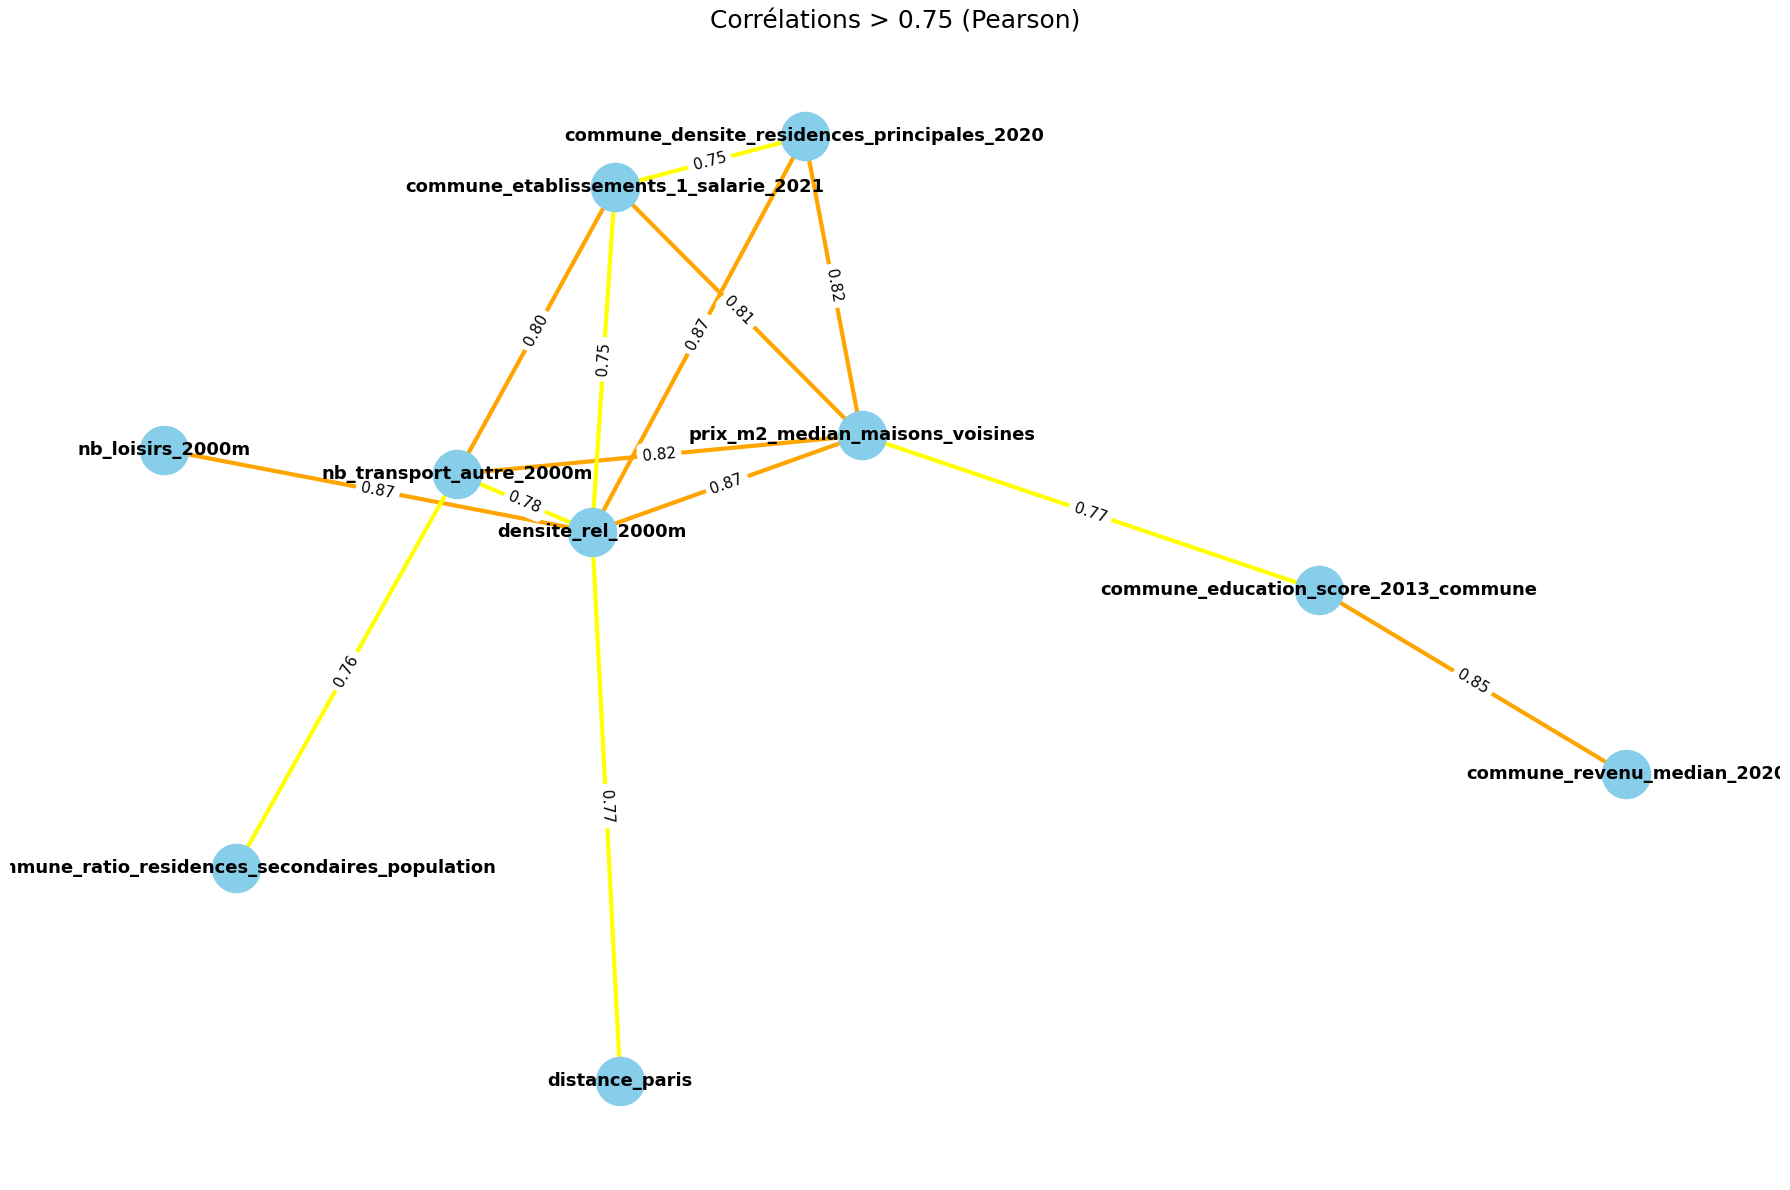

In [ ]:
plot_strong_correlations(X_train, threshold=0.75)

On va tester deux cas :
- options 1 : enlever le prix median des maisons voisines et garder les POI (ceux non corrélés)
- option 2 : garder le prix median des maisons voisines et enlever les POI 

#### Option 1

In [7]:
features_to_drop_1 = [
    "prix_m2_median_maisons_voisines",
    "commune_revenu_median_2020",
    "densite_rel_2000m",
    "commune_etablissements_1_salarie_2021"
]

selected_features_1 = X_train.drop(columns=features_to_drop_1).columns.tolist()

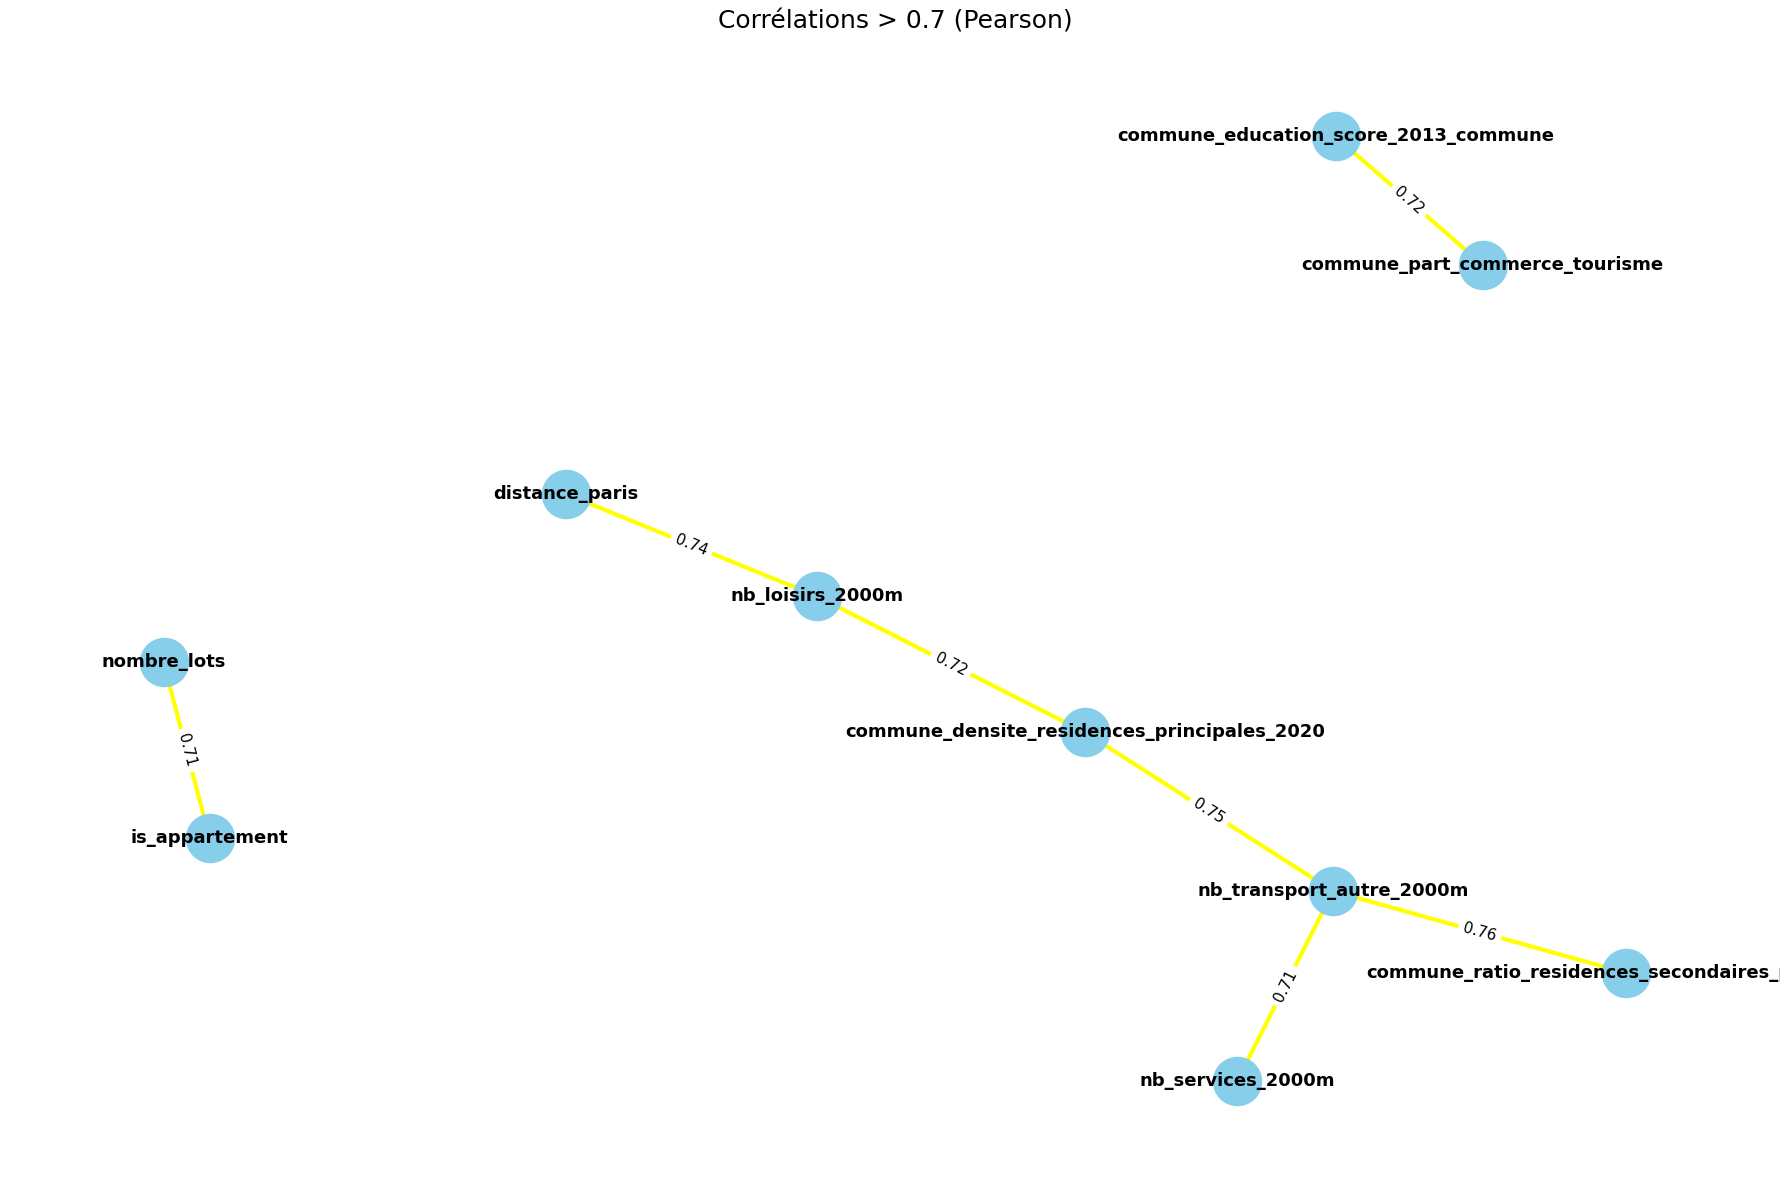

In [8]:
plot_strong_correlations(X_train[selected_features_1], threshold=0.7)

In [9]:
X_train[selected_features_1]

,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,is_appartement,nb_transport_autre_2000m,nombre_lots,commune_part_commerce_tourisme,distance_paris,commune_densite_residences_principales_2020,nombre_pieces_principales,surface_par_piece,commune_ratio_residences_secondaires_population,dist_transport_lourd,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,nb_loisirs_2000m,nb_services_2000m,Evolution_PIB_volume_en_%_base2020_lag4t
0,0.000000,160,0.902589,1,27,1,0.848215,0.042164,14531.034180,3,26.666666,0.095065,268.899414,0.0373,0.325563,290,17,0.193834
1,0.000000,52,0.451268,1,4,1,0.643595,0.073735,5163.738281,2,13.000000,0.013689,319.581665,0.0399,0.282208,235,8,0.900489
2,0.000000,101,0.636588,0,2,1,0.600000,0.288966,231.086960,5,20.200001,0.014819,1018.376892,0.0329,0.811383,33,2,0.506923
3,0.000000,36,0.824937,1,31,1,0.852084,0.021931,15346.884766,1,18.000000,0.093602,272.015564,0.0106,0.370956,307,17,15.361810
4,1.843374,83,0.650801,0,1,0,0.773960,0.127345,3789.773682,5,16.600000,0.016016,992.912659,0.0106,0.483656,228,3,15.361810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507383,0.000000,204,0.549603,1,0,2,0.724356,0.112861,3392.519531,5,20.400000,0.005919,519.641785,0.0284,0.344608,248,10,0.440900
507384,0.000000,92,0.702535,1,4,2,0.761356,0.083150,8104.779785,2,23.000000,0.026443,366.157837,0.0113,0.422412,226,14,-12.214629
507385,0.000000,76,0.234840,0,1,1,0.664062,0.462352,964.067810,4,19.000000,0.004408,1181.921875,0.0113,0.423093,33,3,-12.214629
507386,0.000000,160,0.470862,1,4,1,0.739228,0.138005,3199.401611,3,26.666666,0.014755,279.064087,0.0105,0.283137,331,15,-0.105712


#### Option 2 

In [10]:
features_to_drop_2 = [
    "commune_education_score_2013_commune",
    "densite_rel_2000m",
    "commune_etablissements_1_salarie_2021", 
    'nb_transport_autre_2000m',
    'commune_densite_residences_principales_2020']

selected_features_2 = X_train.drop(columns=features_to_drop_2).columns.tolist()

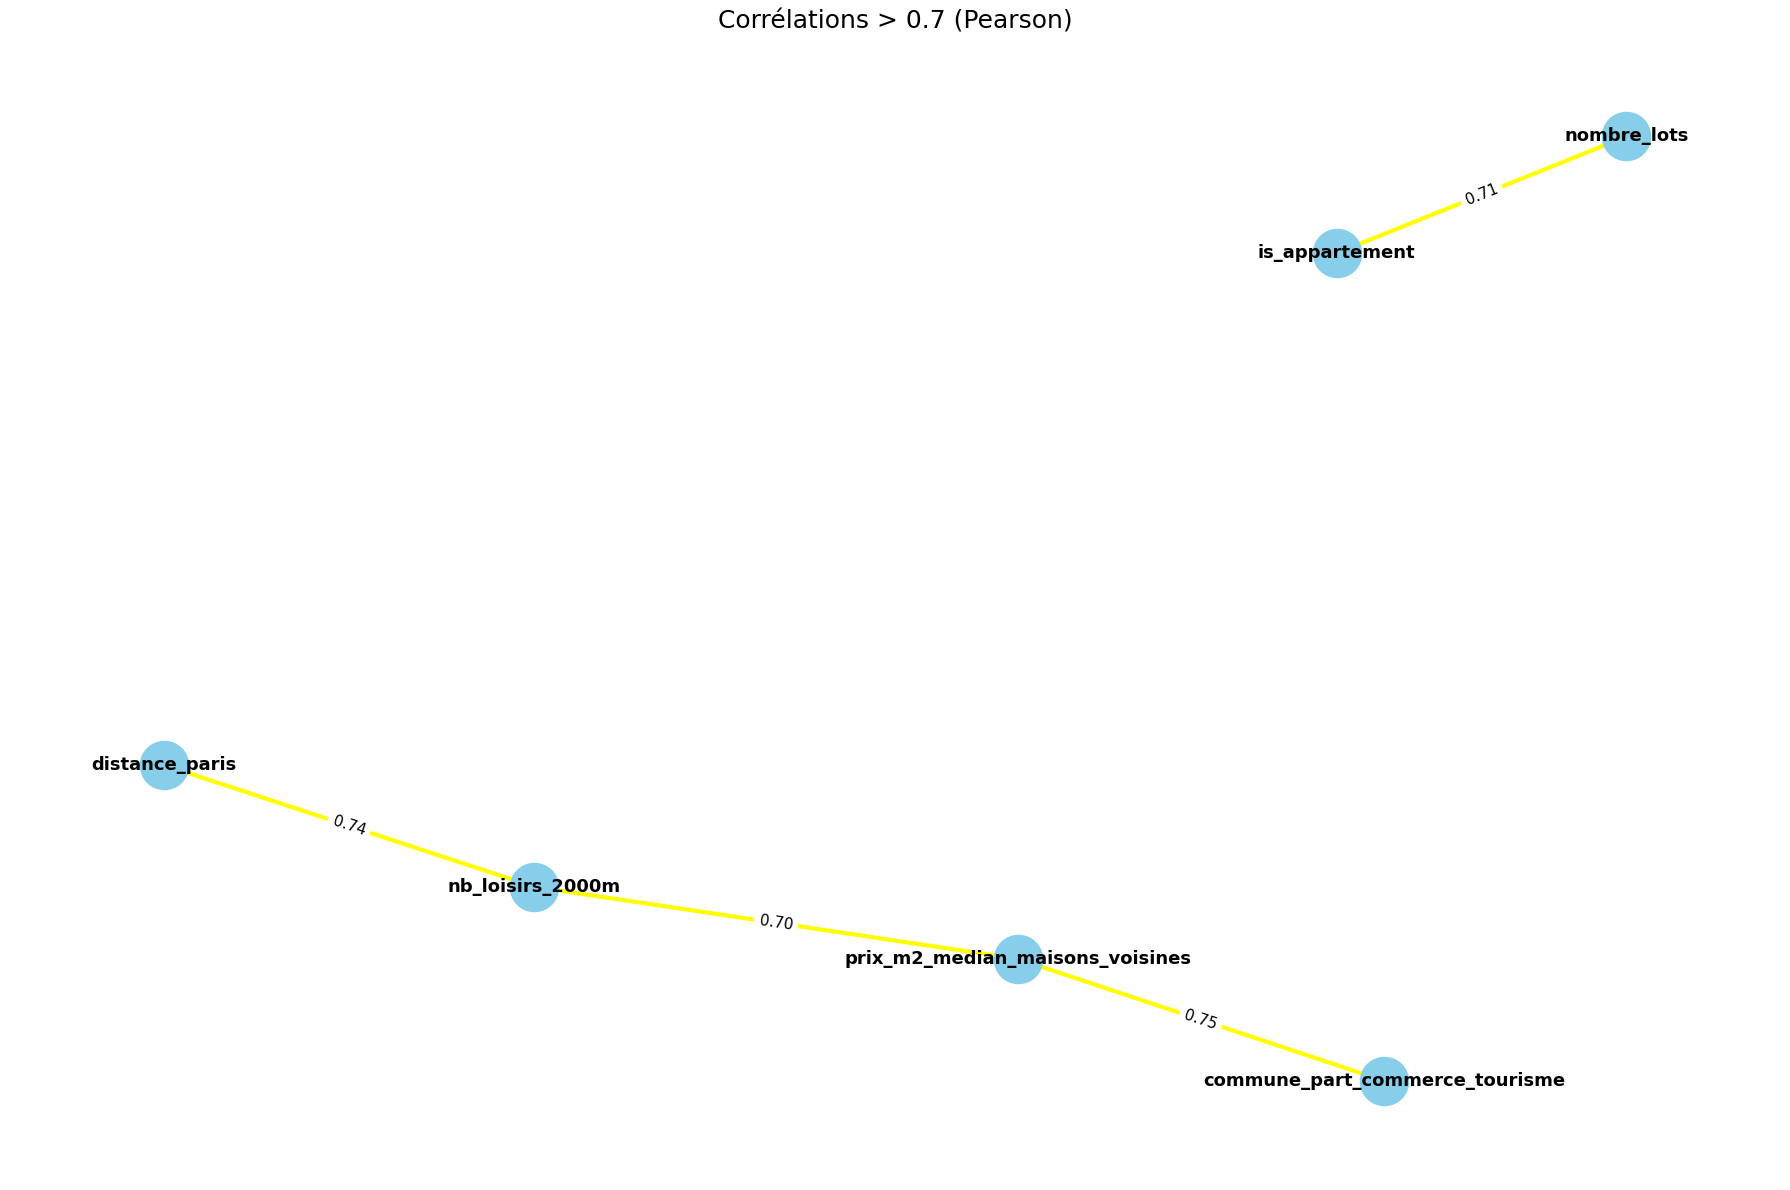

In [11]:
plot_strong_correlations(X_train[selected_features_2], threshold=0.7)

In [12]:
X_train[selected_features_2]

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,is_appartement,nombre_lots,commune_part_commerce_tourisme,distance_paris,nombre_pieces_principales,commune_revenu_median_2020,surface_par_piece,commune_ratio_residences_secondaires_population,dist_transport_lourd,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,nb_loisirs_2000m,nb_services_2000m,Evolution_PIB_volume_en_%_base2020_lag4t
0,9782.608398,0.000000,160,1,1,0.848215,0.042164,3,32120.0,26.666666,0.095065,268.899414,0.0373,0.325563,290,17,0.193834
1,5606.589355,0.000000,52,1,1,0.643595,0.073735,2,18950.0,13.000000,0.013689,319.581665,0.0399,0.282208,235,8,0.900489
2,3152.272705,0.000000,101,0,1,0.600000,0.288966,5,27930.0,20.200001,0.014819,1018.376892,0.0329,0.811383,33,2,0.506923
3,10938.690430,0.000000,36,1,1,0.852084,0.021931,1,28060.0,18.000000,0.093602,272.015564,0.0106,0.370956,307,17,15.361810
4,5555.555664,1.843374,83,0,0,0.773960,0.127345,5,28190.0,16.600000,0.016016,992.912659,0.0106,0.483656,228,3,15.361810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507383,3135.065430,0.000000,204,1,2,0.724356,0.112861,5,20690.0,20.400000,0.005919,519.641785,0.0284,0.344608,248,10,0.440900
507384,7936.507812,0.000000,92,1,2,0.761356,0.083150,2,27310.0,23.000000,0.026443,366.157837,0.0113,0.422412,226,14,-12.214629
507385,1771.571777,0.000000,76,0,1,0.664062,0.462352,4,17960.0,19.000000,0.004408,1181.921875,0.0113,0.423093,33,3,-12.214629
507386,5403.879395,0.000000,160,1,1,0.739228,0.138005,3,21230.0,26.666666,0.014755,279.064087,0.0105,0.283137,331,15,-0.105712


### 2. Traitements et modélisation

In [ ]:
param_grid = {
    'preprocessor__scaler': [StandardScaler(), PowerTransformer(method="yeo-johnson")],
    # 'ridge__alpha': np.logspace(-3, np.log10(0.05), 10)  # de 0.001 à 0.05
    'ridge__alpha': [0, 0.001, 0.02, 0.005]
}

cols_to_scale_1 = [col for col in selected_features_1 if col != 'log_surface_bati']

pipe_1 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("scaler", StandardScaler(), cols_to_scale_1)
    ], remainder='passthrough')),
    ("ridge", Ridge(random_state=42))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe_1, param_grid, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X_train[selected_features_1], y_train)

print("Meilleur score MAE CV :", -grid.best_score_)
print("Meilleure normalisation :", type(grid.best_params_['preprocessor__scaler']).__name__)
print("Meilleur alpha :", grid.best_params_['ridge__alpha'])

Meilleur score MAE CV : 1326.3642112589964
Meilleure normalisation : StandardScaler
Meilleur alpha : 0


In [14]:
cols_to_scale_2 = [col for col in selected_features_2 if col != 'log_surface_bati']

pipe_2 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("scaler", StandardScaler(), cols_to_scale_2)
    ], remainder='passthrough')),
    ("ridge", Ridge(random_state=42))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe_2, param_grid, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X_train[selected_features_2], y_train)

print("Meilleur score MAE CV :", -grid.best_score_)
print("Meilleure normalisation :", type(grid.best_params_['preprocessor__scaler']).__name__)
print("Meilleur alpha :", grid.best_params_['ridge__alpha'])

Meilleur score MAE CV : 1174.7152010617579
Meilleure normalisation : StandardScaler
Meilleur alpha : 0


Pas besoin de pénalisation à priori 

### 3. Interprétabilité 

In [ ]:
# Option 1
best_scaler_1 = grid.best_params_['preprocessor__scaler']
best_alpha_1 = grid.best_params_['ridge__alpha']

model_1 = Pipeline([
    ("scaler", best_scaler_1),
    ("ridge", Ridge(alpha=best_alpha_1, random_state=42))
])
model_1.fit(X_train[selected_features_1], y_train)

y_train_pred_1 = model_1.predict(X_train[selected_features_1])
y_test_pred_1 = model_1.predict(X_test[selected_features_1])

mae_train_1 = mean_absolute_error(y_train, y_train_pred_1)
mae_test_1 = mean_absolute_error(y_test, y_test_pred_1)

print("Option 1 - MAE train:", mae_train_1)
print("Option 1 - MAE test:", mae_test_1)

coeffs_1 = model_1.named_steps['ridge'].coef_
coef_df_1 = pd.DataFrame({'feature': selected_features_1, 'coefficient': coeffs_1})

# Calcul des p-values pour les coefficients du modèle Ridge (approximation via OLS)
X_train_sm = sm.add_constant(X_train[selected_features_1])
ols_model = sm.OLS(y_train, X_train_sm).fit()
pvalues = ols_model.pvalues.drop('const')

coef_df_1['pvalue'] = coef_df_1['feature'].map(pvalues)
coef_df_1.sort_values('coefficient', key=abs, ascending=False)

Option 1 - MAE train: 1326.39207890225
Option 1 - MAE test: 1328.3572908446959


,feature,coefficient,pvalue
2,commune_education_score_2013_commune,911.039706,0.000000e+00
9,nombre_pieces_principales,-768.204258,0.000000e+00
3,is_appartement,-528.918066,0.000000e+00
8,commune_densite_residences_principales_2020,527.101570,0.000000e+00
4,nb_transport_autre_2000m,479.377847,0.000000e+00
15,nb_loisirs_2000m,413.827555,0.000000e+00
1,surface_x_type,355.160348,0.000000e+00
5,nombre_lots,-322.718394,0.000000e+00
10,surface_par_piece,-304.157041,0.000000e+00
16,nb_services_2000m,291.886846,0.000000e+00


In [16]:
# Pour retrouver les coefficients dans l'échelle d'origine des variables
scaler_1 = model_1.named_steps['scaler']
ridge_1 = model_1.named_steps['ridge']

coef_orig_1 = ridge_1.coef_ / scaler_1.scale_
intercept_orig_1 = ridge_1.intercept_ - np.sum(ridge_1.coef_ * scaler_1.mean_ / scaler_1.scale_)

coef_df_orig_1 = pd.DataFrame({'feature': selected_features_1, 'coefficient_orig': coef_orig_1})
coef_df_orig_1.sort_values('coefficient_orig', key=abs, ascending=False)

print('Intercept (échelle originale) :', intercept_orig_1)
coef_df_orig_1

Intercept (échelle originale) : 4957.033327517265


,feature,coefficient_orig
0,ratio_terrain_bati,11.584373
1,surface_x_type,6.625798
2,commune_education_score_2013_commune,4624.385670
3,is_appartement,-1128.782387
4,nb_transport_autre_2000m,41.246868
5,nombre_lots,-335.944432
6,commune_part_commerce_tourisme,1008.824374
7,distance_paris,-991.802580
8,commune_densite_residences_principales_2020,0.096326
9,nombre_pieces_principales,-498.868576


In [20]:
# Option 2
best_scaler_2 = grid.best_params_['preprocessor__scaler']
best_alpha_2 = grid.best_params_['ridge__alpha']


model_2 = Pipeline([
    ("scaler", best_scaler_2),
    ("ridge", Ridge(alpha=best_alpha_2, random_state=42))
])
model_2.fit(X_train[selected_features_2], y_train)

y_train_pred_2 = model_2.predict(X_train[selected_features_2])
y_test_pred_2 = model_2.predict(X_test[selected_features_2])

mae_train_2 = mean_absolute_error(y_train, y_train_pred_2)
mae_test_2 = mean_absolute_error(y_test, y_test_pred_2)

print("Option 2 - MAE train:", mae_train_2)
print("Option 2 - MAE test:", mae_test_2)

coeffs_2 = model_2.named_steps['ridge'].coef_
coef_df_2 = pd.DataFrame({'feature': selected_features_2, 'coefficient': coeffs_2})

# Calcul des p-values pour les coefficients du modèle Ridge (approximation via OLS)
X_train_sm_2 = sm.add_constant(X_train[selected_features_2])
ols_model_2 = sm.OLS(y_train, X_train_sm_2).fit()
pvalues_2 = ols_model_2.pvalues.drop('const')

coef_df_2['pvalue'] = coef_df_2['feature'].map(pvalues_2)
coef_df_2.sort_values('coefficient', key=abs, ascending=False)

Option 2 - MAE train: 1174.7878166260996
Option 2 - MAE test: 1173.1931827775497


,feature,coefficient,pvalue
0,prix_m2_median_maisons_voisines,2008.368349,0.000000e+00
7,nombre_pieces_principales,-635.391929,0.000000e+00
8,commune_revenu_median_2020,425.507223,0.000000e+00
3,is_appartement,-401.240304,0.000000e+00
13,commune_taux_proprietaires,-360.487484,0.000000e+00
4,nombre_lots,-315.805994,0.000000e+00
9,surface_par_piece,-281.603727,0.000000e+00
2,surface_x_type,251.323516,1.946646e-291
1,ratio_terrain_bati,152.838013,0.000000e+00
14,nb_loisirs_2000m,149.181819,3.667009e-216


In [18]:
# Pour retrouver les coefficients dans l'échelle d'origine des variables
scaler_2 = model_2.named_steps['scaler']
ridge_2 = model_2.named_steps['ridge']

coef_orig_2 = ridge_2.coef_ / scaler_2.scale_
intercept_orig_2 = ridge_2.intercept_ - np.sum(ridge_2.coef_ * scaler_2.mean_ / scaler_2.scale_)
coef_df_orig_2 = pd.DataFrame({'feature': selected_features_2, 'coefficient_orig': coef_orig_2})
coef_df_orig_2 = coef_df_orig_2.sort_values('coefficient_orig', key=abs, ascending=False)

print('Intercept (échelle originale) :', intercept_orig_2)
coef_df_orig_2

Intercept (échelle originale) : 3658.8191264879083


,feature,coefficient_orig
12,Taux_moyen_credit_immo_lag1t,-9339.739506
13,commune_taux_proprietaires,-2128.315126
10,commune_ratio_residences_secondaires_population,1030.106690
3,is_appartement,-856.300847
6,distance_paris,-585.939064
7,nombre_pieces_principales,-412.620815
4,nombre_lots,-328.748738
5,commune_part_commerce_tourisme,59.289622
9,surface_par_piece,-42.069604
1,ratio_terrain_bati,11.295952
